In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier, XGBRegressor

from lazypredict import LazyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv("Australia_Meteo_preprocess_4.csv")

In [3]:
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'season']
for c in cat_cols:
    df[c] = df[c].astype('category')

target_cols = ['RainTomorrow', 'RainInTwoDays', 'MaxTempTomorrow','MaxTempInTwoDays']
feature_cols = [c for c in df.columns if c not in target_cols]
len(feature_cols), feature_cols

(23,
 ['Unnamed: 0',
  'Location',
  'MinTemp',
  'MaxTemp',
  'Rainfall',
  'Evaporation',
  'Sunshine',
  'WindGustDir',
  'WindGustSpeed',
  'WindDir9am',
  'WindDir3pm',
  'WindSpeed9am',
  'WindSpeed3pm',
  'Humidity9am',
  'Humidity3pm',
  'Pressure9am',
  'Pressure3pm',
  'Cloud9am',
  'Cloud3pm',
  'Temp9am',
  'Temp3pm',
  'RainToday',
  'season'])

In [5]:
#set a random state 
random_state = 0

# Predict Rain Tomorrow

### Train / test split

In [6]:
target_name = 'RainTomorrow'
sub1 = df.dropna(subset=target_name)
X1 = sub1[feature_cols]
y1 = sub1[target_name].astype(int)

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=random_state, stratify=y1
)

print(X1_train.shape, X1_test.shape)
print("train rain rate:", round(y1_train.mean(), 3), " test rain rate:", round(y1_test.mean(), 3))

(112629, 23) (28158, 23)
train rain rate: 0.222  test rain rate: 0.222


### Imputation MEDIAN AND MODE

In [7]:
numerical_column = X1_train.select_dtypes(include = ['float64']).columns.tolist()
numerical_column

for location in X1_train['Location'].unique():
    df_location = X1_train[X1_train['Location']==location]
    #print('\n')
    for var in numerical_column:
        if((var!='RainToday') and (var!='Rainfall')):
            median = X1_train[X1_train['Location']==location][var].dropna().median()

            X1_train.loc[X1_train['Location'] == location, var] = X1_train.loc[X1_train['Location'] == location, var].fillna(median)

In [8]:
categorical_column = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for location in X1_train['Location'].unique():
    loc_mask = X1_train['Location'] == location
    for var in categorical_column:
        pct_nan = round(100 * X1_train.loc[loc_mask, var].isna().sum() / loc_mask.sum(), 1)
        if pct_nan < 100:
            mode = X1_train.loc[loc_mask, var].dropna().mode()[0]
            X1_train.loc[loc_mask, var] = X1_train.loc[loc_mask, var].fillna(mode)
        else:
            # a few locations have 100% missing WindGustDir - fall back to the WindDir9am mode there
            mode = X1_train.loc[loc_mask, 'WindDir9am'].mode()[0]
            X1_train.loc[loc_mask, var] = X1_train.loc[loc_mask, var].fillna(mode)

### Hyperparameter search for XGBClassifier

In [20]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

def tune_xgb_classifier(X_search,y_search, param_dist,random_state, n_iter=100, cv=3):    
    spw_search = (y_search == 0).sum() / (y_search == 1).sum()
    base = XGBClassifier(
        tree_method='hist', enable_categorical=True, scale_pos_weight=spw_search,
        eval_metric='aucpr', random_state=random_state, n_jobs=-1)

    search = RandomizedSearchCV(
        base, param_dist, n_iter=n_iter, scoring='f1', cv=cv,
        random_state=random_state, n_jobs=1, verbose=1)
    t0 = time.time()
    search.fit(X_search, y_search)
    print(f"search done in {(time.time()-t0)/60.0:.0f}min, best CV ROC-AUC = {search.best_score_:.4f}")
    print("best params:", search.best_params_)

    spw_full = (y_search == 0).sum() / (y_search == 1).sum()
    final_model = XGBClassifier(
        tree_method='hist', enable_categorical=True, scale_pos_weight=spw_full,
        eval_metric='aucpr', random_state=random_state, n_jobs=-1, **search.best_params_)
    t0 = time.time()
    final_model.fit(X_search, y_search)
    print(f"refit on full train done in {time.time()-t0:.0f}s")
    return final_model, search

###########################################################

def evaluate_classifier(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]



    lignes = []
    lignes.append({
        'Modele': 'XGBoost',
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
    })

    comparaison = pd.DataFrame(lignes).sort_values('F1', ascending=False).reset_index(drop=True)
    print(comparaison.round(4).to_string(index=False))

    print('\n')
    
    print(classification_report(y_test, y_pred, digits=3))

    print('\n')
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {auc:.4f}")

    fig, axs = plt.subplots(1, 3, figsize=(16, 4))

    fper, tper, _ = roc_curve(y_test, y_proba)
    axs[0].plot(fper, tper, color='orange', label=f'ROC (AUC={auc:.3f})')
    axs[0].plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    axs[0].set_xlabel('False Positive Rate')
    axs[0].set_ylabel('True Positive Rate')
    axs[0].set_title(f'{title} - ROC curve')
    axs[0].legend()

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(ax=axs[1], colorbar=False)
    axs[1].set_title('Confusion matrix (row-normalized)')

    importances = pd.Series(model.feature_importances_, index=model.feature_names_in_)
    importances.sort_values().tail(12).plot.barh(ax=axs[2], color='#4c72b0')
    axs[2].set_title('Top feature importances')

    plt.tight_layout()
    plt.show()
    return auc   

In [10]:
#Search parameter

param_dist = {
    'n_estimators': [200, 300, 400, 600,1000],
    'max_depth': [4, 5, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

cv = 3
n_iter = 100

model_rain_tomorrow, search1 = tune_xgb_classifier(X1_train, y1_train, param_dist,random_state, n_iter, cv)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
search done in 19min, best CV ROC-AUC = 0.6771
best params: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
refit on full train done in 6s


 Modele     F1  ROC_AUC  Precision  Recall  Accuracy
XGBoost 0.6548   0.8928     0.5577  0.7929    0.8148


              precision    recall  f1-score   support

           0      0.933     0.821     0.873     21918
           1      0.558     0.793     0.655      6240

    accuracy                          0.815     28158
   macro avg      0.745     0.807     0.764     28158
weighted avg      0.850     0.815     0.825     28158



ROC-AUC: 0.8928


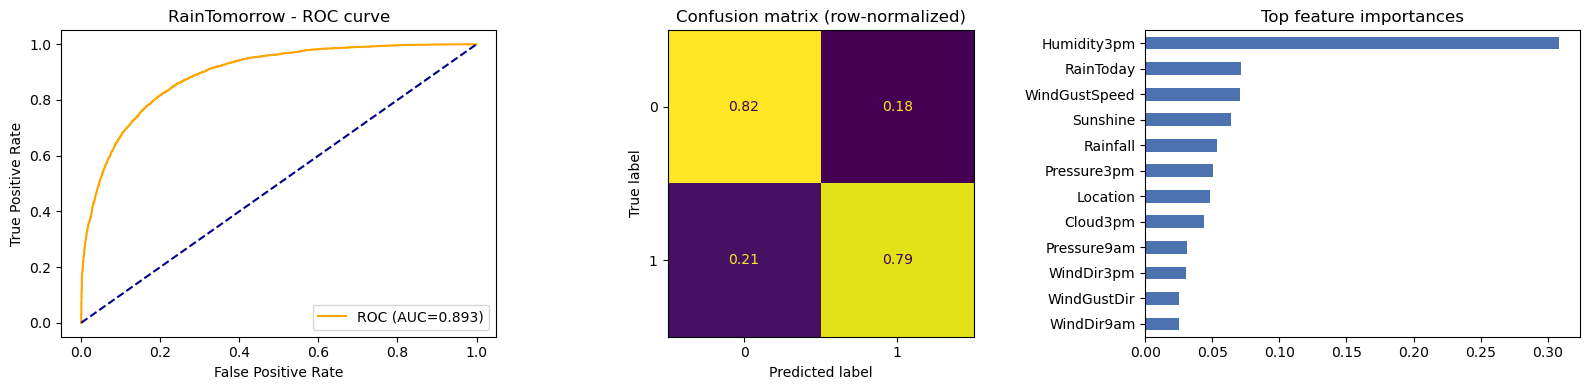

In [21]:
auc1 = evaluate_classifier(model_rain_tomorrow, X1_test, y1_test, target_name)

# Predict Rain in two days

In [22]:
target_name = 'RainInTwoDays'
sub2 = df.dropna(subset=target_name)
X2 = sub2[feature_cols]
y2 = sub2[target_name].astype(int)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=random_state, stratify=y2
)
print(X2_train.shape, X2_test.shape, y2_train.mean())

(110276, 23) (27569, 23) 0.22055569661576407


### Imputation MEDIAN AND MODE

In [23]:
numerical_column = X2_train.select_dtypes(include = ['float64']).columns.tolist()
numerical_column

for location in X2_train['Location'].unique():
    df_location = X2_train[X2_train['Location']==location]
    #print('\n')
    for var in numerical_column:
        if((var!='RainToday') and (var!='Rainfall')):
            median = X2_train[X2_train['Location']==location][var].dropna().median()

            X2_train.loc[X2_train['Location'] == location, var] = X2_train.loc[X2_train['Location'] == location, var].fillna(median)


################################

categorical_column = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for location in X2_train['Location'].unique():
    loc_mask = X2_train['Location'] == location
    for var in categorical_column:
        pct_nan = round(100 * X2_train.loc[loc_mask, var].isna().sum() / loc_mask.sum(), 1)
        if pct_nan < 100:
            mode = X2_train.loc[loc_mask, var].dropna().mode()[0]
            X2_train.loc[loc_mask, var] = X2_train.loc[loc_mask, var].fillna(mode)
        else:
            # a few locations have 100% missing WindGustDir - fall back to the WindDir9am mode there
            mode = X2_train.loc[loc_mask, 'WindDir9am'].mode()[0]
            X2_train.loc[loc_mask, var] = X2_train.loc[loc_mask, var].fillna(mode)

### Hyperparameter search for XGBClassifier

In [24]:
param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [4, 5, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

cv = 3
n_iter = 100

model_rain_2days, search2 = tune_xgb_classifier(X2_train, y2_train, param_dist,random_state, n_iter, cv)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
search done in 15min, best CV ROC-AUC = 0.5040
best params: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
refit on full train done in 4s


 Modele     F1  ROC_AUC  Precision  Recall  Accuracy
XGBoost 0.4942   0.7632     0.3775  0.7155     0.677


              precision    recall  f1-score   support

           0      0.892     0.666     0.763     21489
           1      0.377     0.715     0.494      6080

    accuracy                          0.677     27569
   macro avg      0.635     0.691     0.628     27569
weighted avg      0.779     0.677     0.704     27569



ROC-AUC: 0.7632


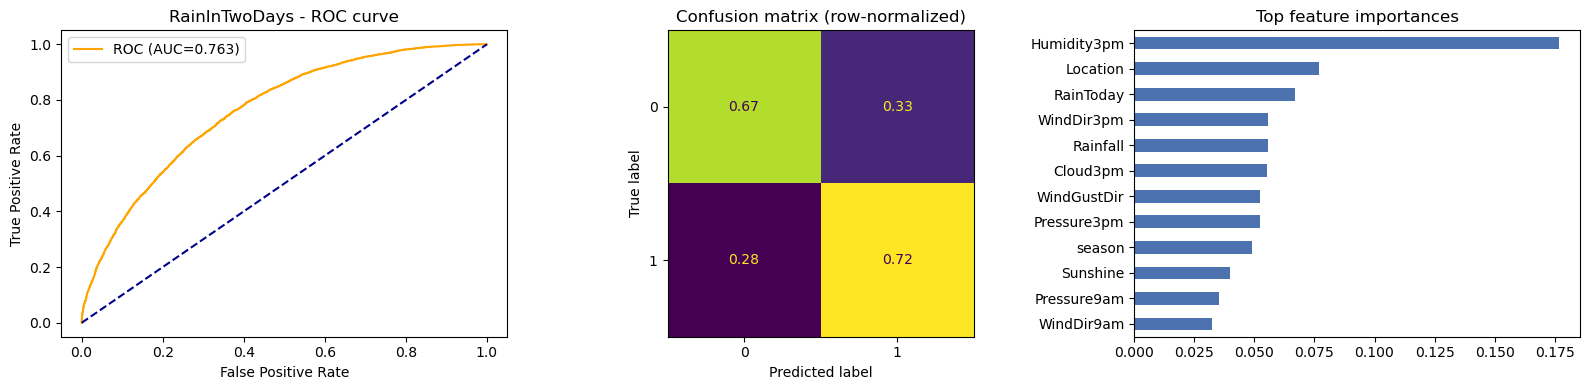

In [25]:
auc2 = evaluate_classifier(model_rain_2days, X2_test, y2_test, target_name)

Predict Maximum temperature tomorrow

### Predict Max temperature tomorrow

In [13]:
target_name = 'MaxTempTomorrow'
sub3 = df.dropna(subset=[target_name])
X3 = sub3[feature_cols]
y3 = sub3[target_name]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=0)
X3_train.shape, X3_test.shape

((112629, 26), (28158, 26))

### Imputation MEDIAN AND MODE

In [ ]:
numerical_column = X3_train.select_dtypes(include = ['float64']).columns.tolist()
numerical_column

for location in X3_train['Location'].unique():
    df_location = X3_train[X3_train['Location']==location]
    #print('\n')
    for var in numerical_column:
        if((var!='RainToday') and (var!='Rainfall')):
            median = X3_train[X3_train['Location']==location][var].dropna().median()

            X3_train.loc[X3_train['Location'] == location, var] = X3_train.loc[X1_train['Location'] == location, var].fillna(median)


################################

categorical_column = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for location in X3_train['Location'].unique():
    loc_mask = X3_train['Location'] == location
    for var in categorical_column:
        pct_nan = round(100 * X3_train.loc[loc_mask, var].isna().sum() / loc_mask.sum(), 1)
        if pct_nan < 100:
            mode = X3_train.loc[loc_mask, var].dropna().mode()[0]
            X3_train.loc[loc_mask, var] = X3_train.loc[loc_mask, var].fillna(mode)
        else:
            # a few locations have 100% missing WindGustDir - fall back to the WindDir9am mode there
            mode = X3_train.loc[loc_mask, 'WindDir9am'].mode()[0]
            X3_train.loc[loc_mask, var] = X3_train.loc[loc_mask, var].fillna(mode)

### Hyperparameter search for XGBClassifier

In [14]:
def tune_xgb_regressor(X_search, y_search, param_dist,random_state, n_iter=100, cv=3):

    base = XGBRegressor(tree_method='hist', enable_categorical=True, random_state=random_state, n_jobs=-1)
    search = RandomizedSearchCV(
        base, param_dist, n_iter=n_iter, scoring='neg_mean_absolute_error', cv=cv,
        random_state=random_state, n_jobs=1, verbose=1,
    )
    t0 = time.time()
    search.fit(X_search, y_search)
    print(f"search done in {time.time()-t0:.0f}s, best CV MAE = {-search.best_score_:.3f}")
    print("best params:", search.best_params_)

    final_model = XGBRegressor(
        tree_method='hist', enable_categorical=True, random_state=random_state, n_jobs=-1, **search.best_params_,
    )
    t0 = time.time()
    final_model.fit(X_search, y_search)
    print(f"refit on full train done in {time.time()-t0:.0f}s")
    return final_model, search


def evaluate_regression(model,X_test,y_test,title):

    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    print(f"MAE  = {mae:.2f} C")
    print(f"RMSE = {rmse:.2f} C")
    print(f"R2   = {r2:.3f}")
    
    fig, axs = plt.subplots(1, 3, figsize=(16, 4))
    
    axs[0].scatter(y_test, y_pred, s=4, alpha=0.15, color='#4c72b0')
    lims = [y_test.min(), y_pred.max()]
    axs[0].plot(lims, lims, color='darkorange', linestyle='--')
    axs[0].set_xlabel('Actual MaxTemp tomorrow (C)')
    axs[0].set_ylabel('Predicted (C)')
    axs[0].set_title('Predicted vs actual')
    
    residuals = y_test - y_pred
    axs[1].hist(residuals, bins=50, color='#55a868')
    axs[1].axvline(0, color='black', linestyle='--')
    axs[1].set_xlabel('Residual (actual - predicted), C')
    axs[1].set_title('Residuals')
    
    importances = pd.Series(model_temp_tomorrow.feature_importances_, index=model_temp_tomorrow.feature_names_in_)
    importances.sort_values().tail(12).plot.barh(ax=axs[2], color='#4c72b0')
    axs[2].set_title('Top feature importances')
    
    plt.tight_layout()
    plt.show()
    return mae


In [15]:
param_dist_reg = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

cv = 3
n_iter = 100

model_temp_tomorrow, search3 = tune_xgb_regressor(X3_train, y3_train, param_dist,random_state, n_iter, cv)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
search done in 761s, best CV MAE = 1.936
best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 0.85}
refit on full train done in 7s


MAE  = 1.91 C
RMSE = 2.67 C
R2   = 0.858


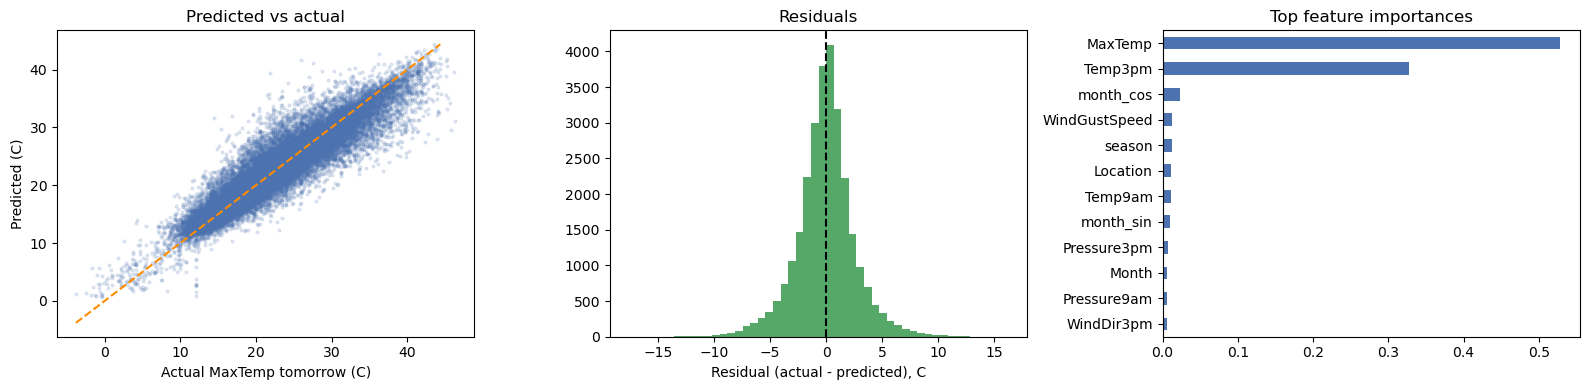

In [16]:
mae1= evaluate_regression(model_temp_tomorrow,X3_test,y3_test,target_name)

### Predict Max temperature in two days

In [17]:
target_name = 'MaxTempInTwoDays'
sub4 = df.dropna(subset=[target_name])
X4 = sub4[feature_cols]
y4 = sub4[target_name]

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=0)
X4_train.shape, X4_test.shape

((112629, 26), (28158, 26))

### Imputation MEDIAN AND MODE

In [ ]:
numerical_column = X4_train.select_dtypes(include = ['float64']).columns.tolist()
numerical_column

for location in X4_train['Location'].unique():
    df_location = X4_train[X4_train['Location']==location]
    #print('\n')
    for var in numerical_column:
        if((var!='RainToday') and (var!='Rainfall')):
            median = X4_train[X4_train['Location']==location][var].dropna().median()

            X4_train.loc[X4_train['Location'] == location, var] = X4_train.loc[X1_train['Location'] == location, var].fillna(median)


################################

categorical_column = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for location in X4_train['Location'].unique():
    loc_mask = X4_train['Location'] == location
    for var in categorical_column:
        pct_nan = round(100 * X4_train.loc[loc_mask, var].isna().sum() / loc_mask.sum(), 1)
        if pct_nan < 100:
            mode = X4_train.loc[loc_mask, var].dropna().mode()[0]
            X4_train.loc[loc_mask, var] = X4_train.loc[loc_mask, var].fillna(mode)
        else:
            # a few locations have 100% missing WindGustDir - fall back to the WindDir9am mode there
            mode = X4_train.loc[loc_mask, 'WindDir9am'].mode()[0]
            X4_train.loc[loc_mask, var] = X4_train.loc[loc_mask, var].fillna(mode)

### Hyperparameter search for XGBClassifier

In [18]:
param_dist_reg = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

cv = 3
n_iter = 100

model_temp_in_two_days, search4 = tune_xgb_regressor(X4_train, y4_train, param_dist,random_state, n_iter, cv)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
search done in 777s, best CV MAE = 2.443
best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
refit on full train done in 4s


MAE  = 2.40 C
RMSE = 3.27 C
R2   = 0.787


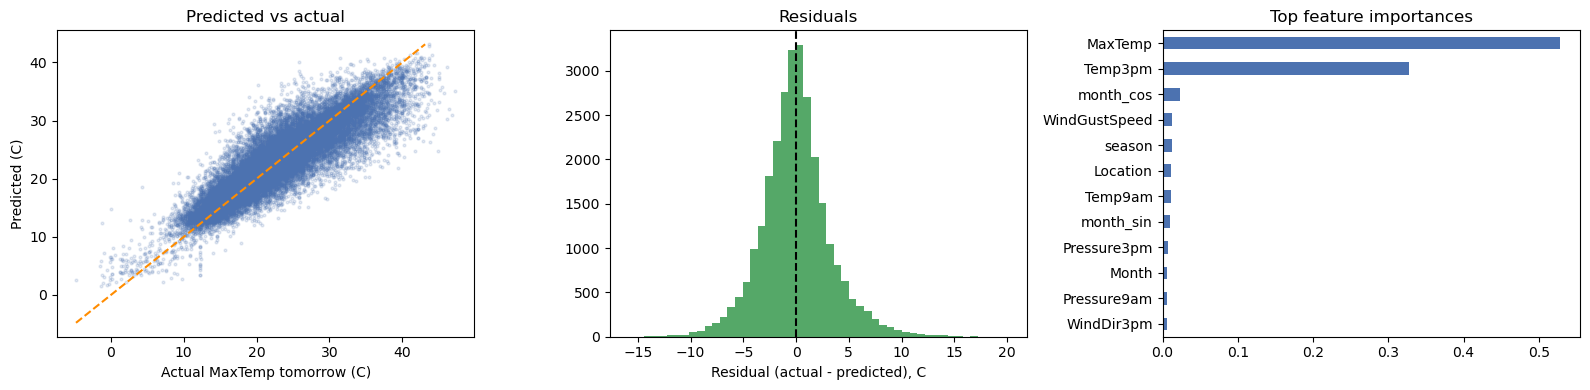

In [19]:
mae2= evaluate_regression(model_temp_in_two_days,X4_test,y4_test,target_name)

### Save the models

In [21]:
joblib.dump(model_rain_tomorrow, "models/model_rain_tomorrow.joblib")
joblib.dump(model_rain_2days, "models/model_rain_in_two_days.joblib")
joblib.dump(model_temp_tomorrow, "models/model_max_temp_tomorrow.joblib")
joblib.dump(model_temp_in_two_days, "models/model_temp_in_two_days.joblib")

pd.DataFrame({
    'objective': ['RainTomorrow', 'RainInTwoDays', 'MaxTempTomorrow','MaxTempInTwoDays'],
    'metric': ['ROC-AUC', 'ROC-AUC', 'MAE (C)','MAE (C)'],
    'score': [round(auc1, 4), round(auc2, 4), round(mae1, 3), round(mae2, 3)],
})

,objective,metric,score
0,RainTomorrow,ROC-AUC,0.9040
1,RainInTwoDays,ROC-AUC,0.7724
2,MaxTempTomorrow,MAE (C),1.9120
3,MaxTempInTwoDays,MAE (C),2.4010


## Random Check with a sample

In [25]:
sample_row = X1_test.sample(1)
print("rain tomorrow probability   :", round(model_rain_tomorrow.predict_proba(sample_row)[0, 1], 3))
print("rain in 2 days probability  :", round(model_rain_2days.predict_proba(sample_row.reindex(columns=X2_train.columns))[0, 1], 3))
print("predicted max temp tomorrow :", round(model_temp_tomorrow.predict(sample_row.reindex(columns=X3_train.columns))[0], 1), "C")
print("predicted max temp in 2days :", round(model_temp_in_two_days.predict(sample_row.reindex(columns=X4_train.columns))[0], 1), "C")
sample_row

rain tomorrow probability   : 0.054
rain in 2 days probability  : 0.153
predicted max temp tomorrow : 14.3 C
predicted max temp in 2days : 13.6 C


,Unnamed: 0,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,season,Month,month_sin,month_cos
47174,47174,Hobart,2.5,13.5,0.2,1.6,1.0,N,37.0,NNW,...,1029.7,6.0,6.0,7.7,13.2,0,Winter,7,-0.5,-0.866025
